### Task 1

In [11]:
import truck
import numpy as np

Truck = truck.Truck()

p = np.array([0.52, 2.16, 0.0, 0.52, 2.68, 0.0, -1.5, 2.7, 0.0])
v = np.zeros_like(p)

x = np.concatenate((p, v))

f = lambda x:Truck(0, x)

jacobian = Truck.jac(f, x)

for _ in range(100):
    dx = np.linalg.solve(-jacobian, f(x))
    norm = np.linalg.norm(dx, ord=None)
    x += dx
    print(_)
    print("This is the jacobi")
    print(dx)
    print("This is the solution")
    print(x)
    print("This is the norm")
    print(norm)

    if norm < 1e-7:
        break

0
This is the jacobi
[-0.02047703 -0.15765764  0.00260413 -0.01904593  0.22947766  0.00260413
 -0.02529209  0.25616442 -0.02094135 -0.         -0.         -0.
 -0.         -0.         -0.         -0.         -0.         -0.        ]
This is the solution
[ 4.99522966e-01  2.00234236e+00  2.60412619e-03  5.00954070e-01
  2.90947766e+00  2.60412609e-03 -1.52529209e+00  2.95616442e+00
 -2.09413518e-02  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00]
This is the norm
0.3808017744597869
1
This is the jacobi
[ 0.00027122 -0.00140718 -0.00147918 -0.00054244 -0.00546015 -0.00147918
  0.00479072 -0.08614428  0.03420454 -0.         -0.         -0.
 -0.         -0.         -0.         -0.         -0.         -0.        ]
This is the solution
[ 4.99794186e-01  2.00093518e+00  1.12494565e-03  5.00411627e-01
  2.90401752e+00  1.12494565e-03 -1.52050137e+00  2.87002014e+00
  1.32631868e-02  0.00000000e+00

### Task 2

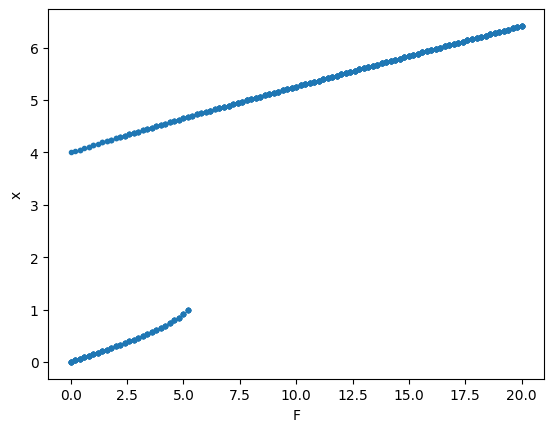

In [12]:
from numpy import *
from math import cos, atan
from scipy.optimize import newton
import matplotlib.pyplot as plt

s = linspace(0, 1, 11)
f = lambda x: 20*(2-x)*(cos(atan(2))-cos(atan(2-x)))
plot_x = []
plot_y = []
for F in linspace(0,20,101):
    for x0 in linspace(0,5,11):
        xast = zeros_like(s)
        xast[0] = x0
        i = 0
        try:
            for _, si in enumerate(s):
                homotop = lambda x: f(x) + (si-1)*f(x0) + F
                xast[i] = newton(homotop, xast[i-1])
                i += 1
            plot_x.append(F)
            plot_y.append(xast[-1])
        except:
            continue
plt.plot(plot_x,plot_y,".")
plt.xlabel("F")
plt.ylabel("x")
plt.show()

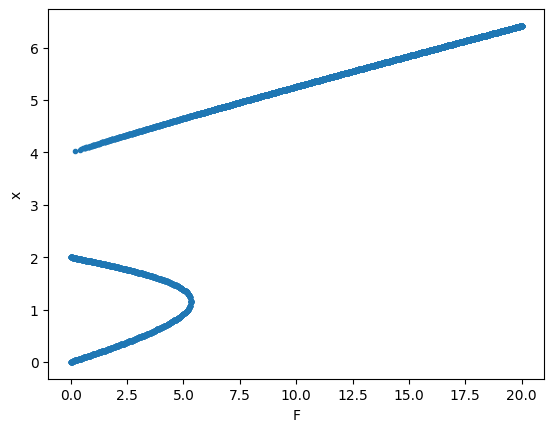

In [13]:
f = lambda t: 20*t*(cos(atan(2))-cos(atan(t)))
plot_x = []
plot_y = []
for F in linspace(0,20,401):
    for t0 in linspace(0,5,26):
        tast = zeros_like(s)
        tast[0] = t0
        i = 0
        try:
            for _, si in enumerate(s):
                homotop = lambda t: f(t) + (si-1)*f(t0) + F
                tast[i] = newton(homotop, tast[i-1])
                i += 1
            plot_x.append(F)
            plot_y.append(2-tast[-1])
        except:
            continue
plt.plot(plot_x,plot_y,".")
plt.xlabel("F")
plt.ylabel("x")
plt.show()

### Task 3

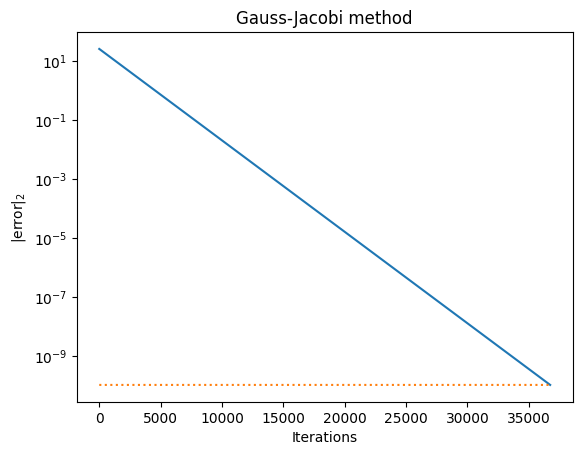

In [14]:
import scipy.linalg as sl

# Setting up a problem with a positive definite matrix

A=array([1,2,0,6,7,0,-3,25,8,6,0,0,7,8,0,7]).reshape((4,-1))
A=A@A.T
b=arange(4)

# Classical way to solve

x_class = sl.solve(A,b)

# Gauss-Jacobi

n=4
x=zeros((n,))

error=[]
eps=1.e-10
for k in range(300000):
    x_prev = x
    for i in range(n):
        sum=b[i]
        for j in range(n):
            if i!=j:
                sum-=A[i,j]*x_prev[j]
        x[i]=sum/A[i,i]
    err=sl.norm(x-x_class, 2)
    error.append(err)
    if err < eps:
        break
    
plt.semilogy(range(k+1),error,range(k+1),(k+1)*[eps],':')
plt.title(f'Gauss-Jacobi method')
plt.xlabel('Iterations')
plt.ylabel(r'$\| \mathrm{error}\|_2$')
plt.show()